In [1]:
import pickle
import numpy as np
import networkx as nx
from qiskit_qaoa.utils.transpiler_passes import ExtendedSwapStrategy, CommutingGateRouter, FindCommutingPauliEvolutionsMulti, DecomposePauliZEvolution
from itertools import combinations

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate, CXGate, SwapGate
from qiskit.transpiler import PassManager
from qiskit.converters import dag_to_circuit, circuit_to_dag
from qiskit.circuit import Parameter

from qiskit.transpiler.passes import (
    HighLevelSynthesis, 
    InverseCancellation
)

from qopt_best_practices.transpilation.qaoa_construction_pass import QAOAConstructionPass
from qopt_best_practices.transpilation.swap_cancellation_pass import SwapToFinalMapping

from qiskit_aer import AerSimulator
from qiskit_aer.backends.backendconfiguration import AerBackendConfiguration
from qiskit_aer.primitives import SamplerV2 as Sampler

from qiskit_qaoa.utils.qaoa_circuit_utils import get_mixer_operator, state_prep
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [2]:
with open('/lustre/scratch127/qpg/jc59/hubo/simulation.grid.compilation.trivial.extra0.four0.0.six1.0.pkl', 'rb') as f:
    data = pickle.load(f)
    
N: int = 3
T: int = 3
n = int(np.ceil(np.log2(2*N+1)))
extra = 0

In [3]:
data.keys()

dict_keys(['old_hamiltonian', 0, 1, 2, 3, 4, 5, 6, 7, 8])

In [16]:
swap_depth = 6
edge_map = data[swap_depth]
edge_map

{0: 8, 1: 7, 2: 6, 3: 5, 4: 4, 5: 3, 6: 2, 7: 1, 8: 0}

In [5]:
old_hamiltonian = data['old_hamiltonian']
num_qubits = old_hamiltonian.num_qubits

extended_swap_strat = ExtendedSwapStrategy.from_grid(n, T)

In [6]:
np.any(old_hamiltonian.paulis.z, axis=0)

array([ True,  True, False,  True,  True,  True,  True,  True,  True])

In [7]:
properties = {}
def get_permutation(pass_, dag, time, property_set, count):
    properties["virtual_permutation_layout"] = property_set["virtual_permutation_layout"]

In [8]:
def print_circuit_info(qc, circuit_name):
    print(f'{circuit_name} has {qc.count_ops().get("cz", 0) + qc.count_ops().get("rzz", 0) + qc.count_ops().get("cx", 0)} 2Q gates \
    and {qc.depth(lambda instr: len(instr.qubits) > 1)} 2Q depth')

In [9]:
num_physical_qubits = extended_swap_strat._num_vertices
coupling_map = extended_swap_strat._coupling_map

basis_gates=["sx", "x", "rz", "rzz", "cz", "id"]


print(f'Physical qubits: {num_physical_qubits}')

coupling_map_edge = list(coupling_map)
physical_qubits = list(coupling_map.physical_qubits)
dual_coupling_map = nx.Graph()

for qubit in physical_qubits:
    edges = [edge for edge in coupling_map_edge if edge[0]==qubit]
    for edge1, edge2 in combinations(edges, 2):
        dual_coupling_map.add_edge(tuple(sorted(edge1)), tuple(sorted(edge2)))
edge_colouring = nx.greedy_color(dual_coupling_map, interchange=True)


pm = PassManager(
    [
        HighLevelSynthesis(basis_gates=["PauliEvolution"]), # Not needed if set up circuit as PauliEvolutionGate
        FindCommutingPauliEvolutionsMulti(), 
        CommutingGateRouter(
            extended_swap_strat,
            edge_colouring,
            max_layers=swap_depth,
            perform_extra_swaps=bool(extra)
        ),
        SwapToFinalMapping(),
        DecomposePauliZEvolution(extended_swap_strat._coupling_map),
        HighLevelSynthesis(
            basis_gates=["sx", "x", "rz", "rzz", "cx", "id", "swap"], 
        ),
        InverseCancellation(gates_to_cancel=[CXGate(), SwapGate()]),
    ]
)

cost_qc = QuantumCircuit(num_physical_qubits)
cost_qc.append(PauliEvolutionGate(old_hamiltonian, time=Parameter("c")), [edge_map[i] for i in range(len(edge_map))])
tcost_qc = pm.run(cost_qc, callback=get_permutation)

Physical qubits: 9
12:06:33 - qiskit_qaoa.utils.transpiler_passes - INFO - Max layers needed to apply swap decompose: 6
12:06:33 - qiskit_qaoa.utils.transpiler_passes - INFO - Gates we cannot directly implement: 0
12:06:33 - qiskit_qaoa.utils.transpiler_passes - INFO - []
12:06:33 - qiskit_qaoa.utils.transpiler_passes - INFO - Not implementing those gates


12:06:33 - qiskit_qaoa.utils.transpiler_passes - WARNING - No single neighbour qubit found. Apply a random cx to break loops
12:06:33 - qiskit_qaoa.utils.transpiler_passes - WARNING - No single neighbour qubit found. Apply a random cx to break loops
12:06:33 - qiskit_qaoa.utils.transpiler_passes - WARNING - No single neighbour qubit found. Apply a random cx to break loops
12:06:33 - qiskit_qaoa.utils.transpiler_passes - WARNING - No single neighbour qubit found. Apply a random cx to break loops
12:06:33 - qiskit_qaoa.utils.transpiler_passes - WARNING - No single neighbour qubit found. Apply a random cx to break loops
12:06:33 - qiskit_qaoa.utils.transpiler_passes - WARNING - No single neighbour qubit found. Apply a random cx to break loops
12:06:33 - qiskit_qaoa.utils.transpiler_passes - WARNING - No single neighbour qubit found. Apply a random cx to break loops
12:06:33 - qiskit_qaoa.utils.transpiler_passes - WARNING - No single neighbour qubit found. Apply a random cx to break loops


In [10]:
backend_options = dict(
    method='statevector',
    device='CPU',
    precision='single',
    basis_gates=basis_gates,
)


config = AerSimulator._DEFAULT_CONFIGURATION
config["n_qubits"] = num_physical_qubits
config["basis_gates"] = basis_gates
config = AerBackendConfiguration.from_dict(config)
backend = AerSimulator(configuration=config, coupling_map=extended_swap_strat._coupling_map, **backend_options)
print(f'Num qubits in backend: {backend.configuration().to_dict()["n_qubits"]}')
sampler = Sampler(seed=1).from_backend(backend)

Num qubits in backend: 35


In [11]:
if not 2*N+1 == 2**(int(np.log2(2*N+1))):
    sp = state_prep(N,T)
    mixer = get_mixer_operator(N,T)
    print('Using Grover mixer and state prep')
else:
    sp = None
    mixer = None
    print('Using X mixer and Hadamard state prep')

Using Grover mixer and state prep


In [12]:
p = 1
construction_pass = QAOAConstructionPass(p, init_state=sp, mixer_layer=mixer)
construction_pass.property_set = properties
qaoa_circ = dag_to_circuit(construction_pass.run(circuit_to_dag(tcost_qc)))

# Now transpile to basis gates
basis_gates = ["x", "rz", "ry", "rzz", "cz", "id", "h", "cx"]
t_qaoa_circ = transpile(qaoa_circ, basis_gates=basis_gates)



In [13]:
print_circuit_info(tcost_qc, 'Cost layer')
print(f'Cost layer has {tcost_qc.num_qubits} qubits')

print_circuit_info(t_qaoa_circ, 'QAOA circuit')
print(f'QAOA circuit has {t_qaoa_circ.num_qubits} qubits')

Cost layer has 229 2Q gates     and 185 2Q depth
Cost layer has 9 qubits
QAOA circuit has 582 2Q gates     and 444 2Q depth
QAOA circuit has 9 qubits


In [14]:
tcost_qc.draw(idle_wires=False, fold=-1)

global phase: (-10.15625)*c
                                                                                                                 ┌───┐                       ┌───┐                        ┌───┐               ┌───┐                                                                      ┌───┐                    ┌───┐              ┌───┐                             ┌───┐                                                 ┌─────────────────┐                                                                                                   ┌───┐                                      ┌───┐                                                                                                                                         ┌───┐               ┌───┐                                                                                                                                                                                               ┌───┐                              ┌───┐                                                                                                                                                                                                                                   ┌───┐                  ┌───┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
q_0 -> 0 ─■────────────────────────────────■─────────────────────────────────────────────────────────────────────┤ X ├─■─────────────────────┤ X ├────────────────────────┤ X ├─■─────────────┤ X ├──■───────────────────────────────────────────────────■───────────────┤ X ├─■──────────────────┤ X ├──────────────┤ X ├──────────■──────────────────┤ X ├───────────────────────────────────■─────────────┤ Rz((-0.3125)*c) ├─────────────────────────────────────────────────────────────────────────────■─────────────────────┤ X ├───────────────────■──────────────────┤ X ├──────────────────────────────────■────────────────────────■─────────────────────────────────────────────────────────────────────────────┤ X ├─■─────────────┤ X ├────────────────■──────────────────────────────────────────────────────────────────────────────────────────────■───────────────────────────────────────────────────────────────────────────────┤ X ├────────────────■─────────────┤ X ├─────────────────────────────────────────────────────────────────────────────────────■──────────────────────────────────────────■──────────────────────X──■────────────────────────────────────────────────────────────────────────┤ X ├─■────────────────┤ X ├────────────────────────────────────────────────────────────────────────────────────■──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■────────────────────────────────────────■───────────────────────────────────────────────────────────────────────────────────────────────────■────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────────X─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
          │                                │ZZ(0.3125*c)                    ┌───┐                                └─┬─┘ │ZZ((-0.3125)*c) ┌───┐└─┬─┘                        └─┬─┘ │ZZ(0.9375*c) └─┬─┘┌─┴─┐                  

In [15]:
sp = state_prep(N, T)
sp.decompose('circuit*').draw(fold=-1)

┌───┐                    
q_0: ────────────────────┤ H ├────────────────────
     ┌───┐┌─────────────┐└─┬─┘               ┌───┐
q_1: ┤ X ├┤ Ry(-2.3664) ├──o─────────o───────┤ H ├
     ├───┤└─────────────┘     ┌──────┴──────┐└─┬─┘
q_2: ┤ X ├────────────────────┤ Ry(-1.9106) ├──o──
     └───┘               ┌───┐└─────────────┘     
q_3: ────────────────────┤ H ├────────────────────
     ┌───┐┌─────────────┐└─┬─┘               ┌───┐
q_4: ┤ X ├┤ Ry(-2.3664) ├──o─────────o───────┤ H ├
     ├───┤└─────────────┘     ┌──────┴──────┐└─┬─┘
q_5: ┤ X ├────────────────────┤ Ry(-1.9106) ├──o──
     └───┘               ┌───┐└─────────────┘     
q_6: ────────────────────┤ H ├────────────────────
     ┌───┐┌─────────────┐└─┬─┘               ┌───┐
q_7: ┤ X ├┤ Ry(-2.3664) ├──o─────────o───────┤ H ├
     ├───┤└─────────────┘     ┌──────┴──────┐└─┬─┘
q_8: ┤ X ├────────────────────┤ Ry(-1.9106) ├──o──
     └───┘                    └─────────────┘

In [17]:
t_qaoa_circ.draw(idle_wires=False, fold=-1)

global phase: 895.3539062730941 - 10.15625*γ[0] - 0.001953125*β[0]
          ┌─────────┐       ┌───┐      ┌─────────┐┌───┐┌──────────┐     ┌───┐     ┌──────────┐                                                                                                                                                                                                         ┌───┐                                                ┌───┐                                                                               ┌───┐                       ┌───┐               ┌───┐                                  ┌───┐                                                       ┌────────────────────┐                                                                                                            ┌───┐                                            ┌───┐                                                                                                                                                        ┌───┐                  ┌───┐                                                                                                                                                                                                                    ┌───┐                                    ┌───┐                                                                                                                                                                                                                                                                                                                          ┌───┐                     ┌───┐                                           ┌───┐                                          ┌───┐                                                                                                                                                                                                                                                                                                                                                                               ┌─────────┐     ┌───┐  ┌─────────┐                                                                                                                                                                                                                                                                                             ┌───┐┌──────────┐  ┌─────────┐    ┌─────────┐                                                     ┌───┐    ┌────────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                ┌───────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [63]:
x = [0.0, 0.0]
assigned_circuit = t_qaoa_circ.assign_parameters(x, inplace=False)
sampler_results = sampler.run([assigned_circuit], shots=10000).result()

In [64]:
from collections import Counter


In [67]:
counter = Counter(sampler_results[0].data.c.get_counts())

In [68]:
counter

Counter({'101001011': 47,
         '000001000': 46,
         '110001101': 44,
         '110101001': 43,
         '110010001': 43,
         '100011000': 42,
         '000110010': 41,
         '011011010': 41,
         '000101101': 40,
         '011001001': 40,
         '101101100': 40,
         '100010110': 39,
         '010101100': 39,
         '101000110': 39,
         '011101100': 39,
         '000101100': 39,
         '000110001': 38,
         '000001101': 38,
         '011101001': 38,
         '000101010': 38,
         '010101011': 38,
         '100101010': 38,
         '101000100': 37,
         '100010000': 37,
         '000011011': 36,
         '000011100': 36,
         '110110000': 36,
         '010010010': 36,
         '001001000': 36,
         '000101000': 36,
         '001100010': 36,
         '011000101': 36,
         '100110010': 36,
         '110010010': 36,
         '101110101': 36,
         '000110100': 36,
         '100000000': 36,
         '000000010': 36,
         '10

In [69]:
len(counter.keys())

343

In [70]:
keys = list(counter.keys())
keys.index('000010001')

230

In [23]:
(2*N+1)**T

343

In [24]:
t_sp = transpile(sp, basis_gates=basis_gates)
t_sp.measure_all()
sp_results = sampler.run([t_sp], shots=100000).result()
sp_counter = Counter(sp_results[0].data.meas.get_counts())

In [25]:
len(sp_counter.keys())

343

In [26]:
hamiltonian = old_hamiltonian.apply_layout([edge_map[i] for i in range(num_qubits)], num_physical_qubits)

In [83]:
keys = list(counter.keys())
scores = evaluate_sparse_pauli_samples(keys, hamiltonian)
min_idx = (np.argmin(scores))
min_idxs = np.nonzero(scores == np.min(scores))[0]
for min_idx in min_idxs:
    key = keys[min_idx]
    unmapped = ''.join([key[edge_map[x]] for x in range(len(key))])
    unmapped_slices = [unmapped[i*n:(i+1)*n] for i in range(T)]
    path = [(sum(int(slice[i]) * 2**i for i in range(n))//2, sum(int(slice[i]) * 2**i for i in range(n)) % 2) for slice in unmapped_slices]
    print(path)
# 001011101 

[(2, 1), (1, 1), (0, 1)]
[(2, 1), (1, 1), (0, 0)]
[(1, 1), (0, 1), (2, 1)]
[(1, 0), (2, 0), (0, 1)]
[(0, 0), (1, 0), (2, 1)]
[(1, 1), (0, 1), (2, 0)]
[(1, 0), (2, 0), (0, 0)]
[(0, 0), (1, 0), (2, 0)]


In [ ]:
best = '001011101'
unmapped = ''.join([best[edge_map[x]] for x in range(len(best))])
unmapped # 101110100 -> 5, 3, 1 -> u2-,u1-,u0-

'101110100'

In [28]:
from functools import reduce
from qiskit_qaoa.utils.hamiltonian_utils import indices_to_pauli
from qiskit_qaoa.utils.string_utils import bin_rep

In [46]:
weights = [1,1,1,1,1,1]
V = 6
obj_spo = reduce(
    SparsePauliOp._add,
    [
        (
            reduce(
                SparsePauliOp._add,
                [
                    reduce(
                        SparsePauliOp.compose,
                        [0.5 * (SparsePauliOp('I' * n * T, np.array([1])) + (1 - 2 * bin_rep(i, n)[k]) * indices_to_pauli(t, k, n, T)) for k in range(n)]
                    ) + reduce(
                        SparsePauliOp.compose,
                        [0.5 * (SparsePauliOp('I' * n * T, np.array([1])) + (1 - 2 * bin_rep(i+1, n)[k]) * indices_to_pauli(t, k, n, T)) for k in range(n)]
                    )
                    for t in range(T)
                ],
                SparsePauliOp('I'  * n * T, np.array([0]))
            ) 
            - SparsePauliOp('I' * n * T, [weights[i]]) 
        ) ** 2
        for i in range(0, V, 2)
    ],
    SparsePauliOp('I'  * n * T, np.array([0]))
)

In [31]:
obj_spo = obj_spo.simplify()
obj_spo

SparsePauliOp(['IIIIIIIII', 'IIZIIZIII', 'IIZIIIIIZ', 'IZIIZIIII', 'IZIIZZIII', 'IZIIIIIZI', 'IZIIIIIZZ', 'IZZIZIIII', 'IZZIZZIII', 'IZZIIIIZI', 'IZZIIIIZZ', 'IIIIIZIIZ', 'IIIIZIIZI', 'IIIIZIIZZ', 'IIIIZZIZI', 'IIIIZZIZZ'],
              coeffs=[1.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j,
 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j,
 0.25+0.j, 0.25+0.j])

In [32]:
cons_spo = old_hamiltonian - obj_spo
cons_spo = cons_spo.simplify()

In [73]:
keys = list(counter.keys())
scores = evaluate_sparse_pauli_samples(keys, obj_spo)
min_idx = np.argmin(scores)
min_idxs = np.nonzero(scores == np.min(scores))
# for min_idx in min_idxs[0][:10]:
#     print(min_idx, scores[min_idx], keys[min_idx])
# 110100011 -> 3, 1, 6 N
# 010001100 -> 2, 4, 1 Y
# 001010000 -> 4, 2, 0 Y
# 001100110 -> 
print(np.min(scores))
for min_idx in min_idxs[0][:10]:
    key = keys[min_idx]
    slices = [key[i*3:(i+1)*3] for i in range(3)]
    vals = [sum(int(slice[i]) * 2**i for i in range(3)) // 2 for slice in slices]
    parities = [sum(int(slice[i]) * 2**i for i in range(3)) % 2 for slice in slices]
    print(key)
    print(vals)
    print(parities)
    print()

0.0
001110000
[2, 1, 0]
[0, 1, 0]

110001000
[1, 2, 0]
[1, 0, 0]

100110101
[0, 1, 2]
[1, 1, 1]

010000001
[1, 0, 2]
[0, 0, 0]

110100101
[1, 0, 2]
[1, 1, 1]

101110100
[2, 1, 0]
[1, 1, 1]

110101000
[1, 2, 0]
[1, 1, 0]

100110001
[0, 1, 2]
[1, 1, 0]

000110001
[0, 1, 2]
[0, 1, 0]

010001100
[1, 2, 0]
[0, 0, 1]



In [56]:
keys= ['000000000', '000000010', '000000001', '000000011', '110100011', '000010001']
evaluate_sparse_pauli_samples(keys, obj_spo)

array([6., 2., 2., 3., 1., 0.])

In [34]:
keys = list(counter.keys())
scores = evaluate_sparse_pauli_samples(keys, cons_spo)
min_idx = (np.argmin(scores))
print(min_idx, scores[min_idx], keys[min_idx])
# 001011010100 -> 4, 6, 2, 1 -> u3+, end, u1+, u0- 

52 0.0 000010101000


In [35]:
scores[0:10]

array([20., 21., 10., 11., 21., 21., 10., 20., 14., 11.])

In [36]:
for key in counter.keys():
    key_slices = [key[3*i:3*(i+1)] for i in range(4)]
    if any(slice == '111' for slice in key_slices):
        print(key)

In [37]:
sol = '000000010000000000000010000100000000000000000001000000100000010000000000000010000000000000000100001000000000000000001000000001000000100000000000'
sol = [int(c) for c in sol]
[idx for idx in range(len(sol)) if sol[idx] > 0]

[7, 22, 27, 47, 54, 61, 76, 93, 98, 116, 125, 132]

In [38]:
sol_slices = [sol[12*i:12*(i+1)] for i in range(12)]
sol_slices

[[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
 [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

In [39]:
from pysat.formula import IDPool
num_nodes_g2: int = 12
variable_pool = IDPool(start_from=0)
variables = np.array(
    [
        [variable_pool.id(f"v_{i}_{j}") for j in range(num_nodes_g2)]
        for i in range(12)
    ],
    dtype=int,
)
vid2mapping = {v: idx for idx, v in np.ndenumerate(variables)}

In [40]:
[vid2mapping[idx] for idx in range(len(sol)) if sol[idx] > 0]

[(0, 7),
 (1, 10),
 (2, 3),
 (3, 11),
 (4, 6),
 (5, 1),
 (6, 4),
 (7, 9),
 (8, 2),
 (9, 8),
 (10, 5),
 (11, 0)]

In [74]:
ess = ExtendedSwapStrategy.from_grid(3,4)

In [75]:
3//2

1

In [76]:
ess.distance_matrix

array([[0, 0, 2, 1, 0, 3, 1, 2, 4, 6, 8, 7],
       [0, 0, 0, 2, 1, 0, 2, 3, 8, 4, 7, 6],
       [2, 0, 0, 0, 3, 2, 0, 1, 6, 7, 4, 8],
       [1, 2, 0, 0, 2, 1, 3, 0, 7, 8, 6, 4],
       [0, 1, 3, 2, 0, 0, 1, 2, 0, 1, 3, 2],
       [3, 0, 2, 1, 0, 0, 0, 1, 3, 0, 2, 1],
       [1, 2, 0, 3, 1, 0, 0, 0, 1, 2, 0, 3],
       [2, 3, 1, 0, 2, 1, 0, 0, 2, 3, 1, 0],
       [4, 8, 6, 7, 0, 3, 1, 2, 0, 0, 2, 1],
       [6, 4, 7, 8, 1, 0, 2, 3, 0, 0, 0, 2],
       [8, 7, 4, 6, 3, 2, 0, 1, 2, 0, 0, 0],
       [7, 6, 8, 4, 2, 1, 3, 0, 1, 2, 0, 0]])

{(0, 0): Text(0.451147849879419, 1.0, '0'),
 (0, 1): Text(-0.26990252479114213, 0.7451803946827372, '1'),
 (0, 2): Text(-0.9730638169711774, 0.43796043309679966, '2'),
 (1, 0): Text(0.7406503741318126, 0.28702048563768223, '3'),
 (1, 1): Text(0.0012628052027113246, 0.0021350103554078678, '4'),
 (1, 2): Text(-0.7340926294402811, -0.287265865310936, '5'),
 (2, 0): Text(0.9716497068629595, -0.4425467077528808, '6'),
 (2, 1): Text(0.26548453240175385, -0.743880657589132, '7'),
 (2, 2): Text(-0.453136297276056, -0.9986030931196782, '8')}

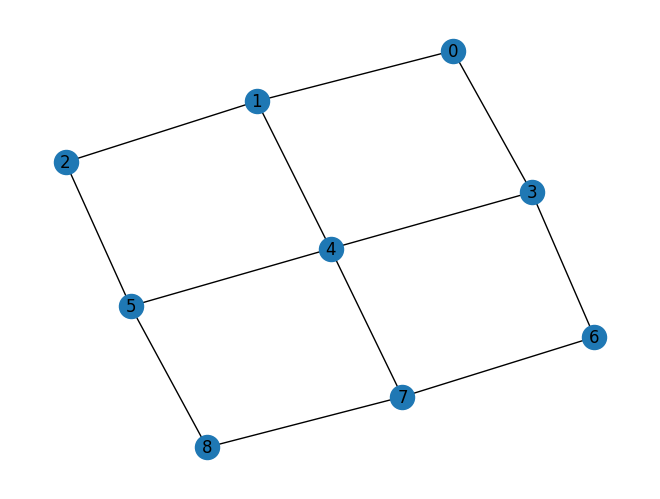

In [47]:
import networkx as nx
g = nx.grid_2d_graph(3,3)
pos = nx.spring_layout(g)
nx.draw(g, pos=pos)
nodes = list(g.nodes)
labels = {nodes[x]: x for x in range(len(nodes))}
nx.draw_networkx_labels(g, pos, {n:lab for n,lab in labels.items() if n in pos})

In [77]:
ess._swap_layers

(((0, 1), (2, 3), (5, 6), (8, 9), (10, 11)),
 ((1, 2), (4, 5), (6, 7), (9, 10)),
 ((0, 1), (2, 3), (5, 6), (8, 9), (10, 11)),
 ((0, 4), (1, 5), (2, 6), (3, 7)),
 ((4, 8), (5, 9), (6, 10), (7, 11)),
 ((0, 1), (2, 3), (5, 6), (8, 9), (10, 11)),
 ((1, 2), (4, 5), (6, 7), (9, 10)),
 ((0, 1), (2, 3), (5, 6), (8, 9), (10, 11)),
 ((0, 4), (1, 5), (2, 6), (3, 7)),
 ((4, 8), (5, 9), (6, 10), (7, 11)))

In [46]:
ess.distance_matrix

array([[0, 0, 1, 0, 2, 1, 3, 6, 5],
       [0, 0, 0, 1, 0, 2, 5, 3, 6],
       [1, 0, 0, 2, 1, 0, 6, 5, 3],
       [0, 1, 2, 0, 0, 1, 0, 1, 2],
       [2, 0, 1, 0, 0, 0, 2, 0, 1],
       [1, 2, 0, 1, 0, 0, 1, 2, 0],
       [3, 5, 6, 0, 2, 1, 0, 0, 1],
       [6, 3, 5, 1, 0, 2, 0, 0, 0],
       [5, 6, 3, 2, 1, 0, 1, 0, 0]])

In [84]:
import uuid
id = uuid.uuid1()
print(f'ID{id}')

ID95fef56a-7e95-11f0-a16b-b16d4007d4c1
